In [20]:
!pwd

/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/datasets/Wikilingual-dataset


In [21]:
%cd "/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/datasets/Wikilingual-dataset"

/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/datasets/Wikilingual-dataset


In [22]:
import re
import unicodedata

def get_tone(word: str):
    tone_map = {
        '\u0300': '<`>',
        '\u0301': '</>',
        '\u0303': '<~>',
        '\u0309': '<?>',
        '\u0323': '<.>',
    }
    decomposed_word = unicodedata.normalize('NFD', word)
    tone = None
    remaining_word = ''
    for char in decomposed_word:
        if char in tone_map:
            tone = tone_map[char]
        else:
            remaining_word += char
    remaining_word = unicodedata.normalize('NFC', remaining_word)

    return tone, remaining_word


def get_onset(word: str) -> tuple[str, str]:
    onsets = ['ngh', 'tr', 'th', 'ph', 'nh', 'ng', 'kh',
              'gi', 'gh', 'ch', 'q', 'đ', 'x', 'v', 't',
              's', 'r', 'n', 'm', 'l', 'k', 'h', 'g', 'd',
              'c', 'b']

    # get the onset
    for onset in onsets:
        if word.startswith(onset):
            if onset != "q":
                word = word.removeprefix(onset)
            return onset, word

    return None, word


def get_medial(word: str) -> tuple[str, str]:
    O_MEDIAL = "o"
    U_MEDIAL = "u"

    if word.startswith("q"):
        # in Vietnamese, words starting with "q" always has "u" as the medial
        word = word.removeprefix("qu")
        return U_MEDIAL, word

    o_medial_cases = ["oa", "oă", "oe"]
    for o_medial_case in o_medial_cases:
        if word.startswith(o_medial_case):
            word = word.removeprefix("o")
            return O_MEDIAL, word

    if word.startswith("ua") or word.startswith("uô"):
        return None, word

    nucleuses = ['ê', 'y', 'ơ', 'a', 'â', 'ya']
    for nucleus in nucleuses:
        component = U_MEDIAL + nucleus
        if word.startswith(component):
            word = word.removeprefix("u")
            return U_MEDIAL, word

    return None, word


def get_nucleus(word: str) -> tuple[str, str]:
    nucleuses = ['oo', 'ươ', 'ưa', 'uô', 'ua', 'iê', 'yê',
                 'ia', 'ya', 'e', 'ê', 'u', 'ư', 'ô', 'i',
                 'y', 'o', 'ơ', 'â', 'a', 'o', 'ă']

    for nucleus in nucleuses:
        if word.startswith(nucleus):
            word = word.removeprefix(nucleus)
            return nucleus, word

    return None, word


def get_coda(word: str) -> str:
    codas = ['ng', 'nh', 'ch', 'u', 'n', 'o',
             'p', 'c', 'm', 'y', 'i', 't', 'k']

    if word in codas:
        return word

    return None


def split_phoneme(word: str) -> list[str, str, str]:
    onset, word = get_onset(word)

    medial, word = get_medial(word)

    nucleus, word = get_nucleus(word)

    coda = get_coda(word)

    return onset, medial, nucleus, coda


def is_Vietnamese(word: str) -> tuple[bool, tuple]:
    tone, word = get_tone(word)
    if not re.match(r"[a-zA-Zăâđưôơê]", word):
        return False, None

    # handling for special cases
    special_words_to_words = {
        "gin": "giin",     # gìn after being removed the tone
        "giêng": "giiêng",  # giếng after being removed the tone
        "giêt": "giiêt",   # giết after being removed the tone
        "giêc": "giiêc",   # giếc (diếc) after being removed the tone
        "gi": "gii"        # gì after removing the tone
    }

    if word in special_words_to_words:
        word = special_words_to_words[word]

    # check the total number of nucleus in word
    vowels = ['oo', 'ươ', 'ưa', 'uô', 'ua', 'iê', 'yê',
              'ia', 'ya', 'e', 'ê', 'u', 'ư', 'ô', 'i',
              'y', 'o', 'ơ', 'â', 'a', 'o', 'ă']
    currentCharacterIsVowels = False
    previousCharacterIsVowels = word[0] in vowels
    foundVowels = 0

    for character in word[1:]:
        if character in vowels:
            currentCharacterIsVowels = True
        else:
            currentCharacterIsVowels = False

        if currentCharacterIsVowels and not previousCharacterIsVowels:
            foundVowels += 1

        # in Vietnamese, each word has only one syllable
        if foundVowels > 2:
            return False, None

        previousCharacterIsVowels = currentCharacterIsVowels

    # in case the word has the structure of a Vietnamese word, we check whether it satisfies the rule of phoneme combination
    onset, medial, nucleus, coda = split_phoneme(word)

    if nucleus is None:
        return False, None

    former_word = ""
    for component in [onset, medial, nucleus, coda]:
        if component is not None:
            former_word += component
    if former_word != word:
        return False, None

    if onset == "k" and medial is None and nucleus not in ["i", "y", "e", "ê", "iê", "yê", "ia", "ya"]:
        return False, None

    if onset == "c" and medial is None and nucleus in ["i", "y", "e", "ê", "iê", "yê", "ia", "ya"]:
        return False, None

    if onset == "q" and not medial == "u":
        return False, None

    if onset == "gh" and medial is None and nucleus not in ["i", "e", "ê", "iê"]:
        return False, None

    if onset == "g" and medial is None and nucleus in ["i", "e", "ê", "iê"]:
        return False, None

    if onset == "ngh" and medial is None and nucleus not in ["i", "e", "ê", "iê", "yê", "ia", "ya"]:
        return False, None

    if onset == "ng" and medial is None and nucleus in ["i", "e", "ê", "iê", "yê", "ia", "ya"]:
        return False, None

    if onset in ["r", "gi"] and medial is not None:
        return False, None

    if medial == "o" and nucleus not in ["a", "ă", "e"]:
        return False, None

    if medial == "u" and nucleus not in ['yê', 'ya', 'e', 'ê', 'y', 'ơ', "ô", 'a', 'â', 'ă']:
        return False, None

    if nucleus == "oo" and coda not in ["ng", "c"]:
        return False, None

    if nucleus == "ua" and coda is not None:
        return False, None

    if nucleus == "ia" and coda is not None:
        return False, None

    if nucleus == "ya" and coda is not None:
        return False, None

    if nucleus in ["ua", "uô"] and coda == "ph":
        return False, None

    if nucleus in ["yê", "iê"] and coda is None:
        return False, None

    if nucleus in ["ă", "â"] and coda is None:
        return False, None

    if medial == "o" and nucleus in ["iê", "yê", "ia", "ya"]:
        return False, None

    if medial is not None:
        if nucleus in ["u", "oo", "o", "ua", "uô", "ươ", "ưa", "ư"]:
            return False, None

        if nucleus in ["i", "e", "ê", "ia", "ya", "iê", "yê"] and coda in ["m", "ph"]:
            return False, None

    if coda == "o" and nucleus not in ["a", "e"]:
        return False, None

    if coda == "y" and nucleus not in ["a", "â"]:
        return False, None

    if coda == "i" and nucleus in ["ă", "â", "i", "e", "iê", "yê", "ia", "ya"]:
        return False, None

    if coda == "nh" and nucleus not in ["a", "i", "y", "ê"]:
        return False, None

    if coda == "ng" and nucleus not in ["a", "o", "ô", "u", "ư", "e", "iê", "ươ", "â", "ă", "uô", "oo"]:
        return False, None

    if coda == "ch" and nucleus not in ["i", "a", "ê", "y"]:
        return False, None

    if coda == "c" and nucleus in ["i", "ê", "e", "ơ"]:
        return False, None

    if nucleus == coda:
        return False, None

    return True, (onset, medial, nucleus, coda, tone)


# def compose_word(onset: str, medial: str, nucleus: str, coda: str, tone: str) -> str:
#     tone_map = {
#         '<`>': '\u0300',
#         '</>': '\u0301',
#         '<~>': '\u0303',
#         '<?>': '\u0309',
#         '<.>': '\u0323'
#     }
#     tone = tone_map[tone]

#     # process for the special case of medial + coda (hỏa, thủy, thuở, thỏa, ...)
#     # in this case, only "thuở" follows the general rule of tone marking, the others are the case that tones are marked on the medial.
#     if onset != "q" and medial is not None and nucleus is not None and coda is None and nucleus != "ơ":
#         medial += tone
#     else:
#         if coda is None:
#             nucleus = nucleus[0] + tone + nucleus[1:]
#         else:
#             nucleus = nucleus + tone

#     word = ""
#     if onset:
#         word += onset
#     if medial:
#         word += medial
#     if nucleus:
#         word += nucleus
#     if coda:
#         word += coda

#     if "gii" in word:
#         word = re.sub("gii", "gi", word)

#     return word

def compose_word(initial: str, rhyme: str, tone: str) -> tuple[str, None]:
    def get_glide(rhyme: str) -> str:
        if rhyme.startswith("w"):
            return "w"

        return None

    def get_final(rhyme: str) -> str:
        possible_finals = ['j', 'm', 'n', 'ŋ̟', 'ŋ', 'p', 'k', 't', 'k̟', 'w']
        for final in possible_finals:
            if rhyme.endswith(final):
                return final

        return None

    initial2_onset = {
        None: [None],
        "m": ["m"],
        "b": ["b"],
        "k": ["c", "k", "q"],
        "v": ["v"],
        "t": ["t"],
        "ʝ": ["d"],
        "d": ["đ"],
        "n": ["n"],
        "r": ["r"],
        "s": ["x"],
        "ʂ": ["s"],
        "l": ["l"],
        "h": ["h"],
        "f": ["ph"],
        "tʰ": ["th"],
        "ɣ": ["g", "gh"],
        "z": ["gi"],
        "t͡ɕ": ["ch"],
        "ʈ͡ʂ": ["tr"],
        "ɲ": ["nh"],
        "ŋ": ["ng", "ngh"],
        "χ": ["kh"],
    }

    glide2medial = {
        None: [None],
        "w": ["u", "o"],
    }

    vowel2nucleus = {
        None: [None],
        "iə": ["iê", "yê", "ia", "ya"],
        "uə": ["uô", "ua"],
        "ɯə": ["ươ", "ưa"],
        "a": ["a"],
        "ă": ["a", "ă"],
        "ə̆": ["â"],
        "i": ["i", "y"],
        "ɛ": ["e"],
        "e": ["ê"],
        "u": ["u"],
        "ɯ": ["ư"],
        "ɔ": ["o"],
        "ɔː": ["oo"],
        "o": ["ô"],
        "ə": ["ơ"],
    }

    final2coda = {
        None: [None],
        "j": ["i", "y"],
        "m": ["m"],
        "n": ["n"],
        "ŋ̟": ["nh"],
        "ŋ": ["ng"],
        "p": ["p"],
        "t": ["t"],
        "k": ["c"],
        "k̟": ["ch"],
        "w": ["u", "o"],
    }

    glide: str = get_glide(rhyme)
    final: str = get_final(rhyme)
    vowel = rhyme
    if glide is not None:
        vowel = vowel.removeprefix(glide)
    if final is not None:
        vowel = vowel.removesuffix(final)

    coda_options = final2coda[final]
    if len(coda_options) == 1:
        coda = coda_options[0]
    else:
        # special cases where we have multiple options for the coda
        if coda_options == ["i", "y"]:
            if vowel in ["ă", "ə̆"]:
                coda = "y"
            else:
                coda = "i"

        if coda_options == ["u", "o"]:
            if vowel in ["ă", "ə̆", "e", "i", "iə", "ɯ", "ɯə"]:
                coda = "u"
            else:
                coda = "o"

    nucleus_options = vowel2nucleus[vowel]
    if len(nucleus_options) == 1:
        nucleus = nucleus_options[0]

    onset_options = initial2_onset[initial]
    if len(onset_options) == 1:
        onset = onset_options[0]

    # special cases where we have multiple options for the nucleus
    if nucleus_options == ["iê", "yê", "ia", "ya"]:
        nucleus = None
        if glide is None and final is None:
            nucleus = "ia"
        if glide is not None and final is None:
            nucleus = "ya"
        if glide is None and final is not None:
            nucleus = "iê"
        if glide is not None and final is not None:
            nucleus = "yê"
        if initial is None and glide is None:
            nucleus = "yê"
        # in the case where the syllabic components are connot correctly given
        if nucleus is None:
            return None

    if nucleus_options == ["uô", "ua"]:
        nucleus = None
        if final is None:
            nucleus = "ua"
        else:
            nucleus = "uô"
        # in the case where the syllabic components are connot correctly given
        if nucleus is None:
            return None

    if nucleus_options == ["ươ", "ưa"]:
        nucleus = None
        if final is None:
            nucleus = "ưa"
        else:
            nucleus = "ươ"
        # in the case where the syllabic components are connot correctly given
        if nucleus is None:
            return None

    if nucleus_options == ["i", "y"]:
        nucleus = None
        if initial is None and glide is None and final is None:
            nucleus = "y"
        elif glide is not None:
            nucleus = "y"
        else:
            nucleus = "i"
        # in the case where the syllabic components are connot correctly given
        if nucleus is None:
            return None

    if nucleus_options == ["a", "ă"]:
        if coda in ["u", "y"]:
            nucleus = "a"
        else:
            nucleus = "ă"

    if onset_options == ["c", "k", "q"]:
        if glide:
            onset = "q"
        else:
            if nucleus in ["i", "y", "e", "ê", "iê", "yê", "ia", "ya"]:
                onset = "k"
            else:
                onset = "c"

    if onset_options == ["ng", "ngh"]:
        if nucleus in ["i", "e", "ê", "iê", "yê", "ia", "ya"] and glide is None:
            onset = "ngh"
        else:
            onset = "ng"

    if onset_options == ["g", "gh"]:
        if nucleus in ["i", "e", "ê", "iê"]:
            onset = "gh"
        else:
            onset = "g"

    medial_options = glide2medial[glide]
    if len(medial_options) == 1:
        medial = medial_options[0]
    else:
        if onset == "q":
            medial = "u"
        else:
            # special cases where we have multiple options for the medial
            if nucleus in ["e", "a", "ă"]:
                medial = "o"
            else:
                medial = "u"

    tone_map = {
        "-": '',
        '˨˩': '\u0300',
        '˧˥': '\u0301',
        '˧ˀ˥': '\u0303',
        '˧˩': '\u0309',
        '˧ˀ˩': '\u0323'
    }
    tone = tone_map[tone]
    # process for the special case of medial + coda (hỏa, thủy, thuở, thỏa, ...)
    # in this case, only thuở, nhuệ/huệ/huề/duệ follows the general rule of tone marking, the others are the case that tones are marked on the medial.
    if onset != "q" and medial is not None and nucleus is not None and coda is None and nucleus not in ["ơ", "ê"]:
        medial += tone
    else:
        if coda is None:
            nucleus = nucleus[0] + tone + nucleus[1:]
        else:
            nucleus = nucleus + tone

    word = ""
    if onset:
        word += onset
    if medial:
        word += medial
    if nucleus:
        word += nucleus
    if coda:
        word += coda

    if "gii" in word:
        word = re.sub("gii", "gi", word)

    word = unicodedata.normalize('NFC', word)

    return word

def convert_Vietnamese_to_IPA(syllable: str) -> list[str]:
    assert re.search(r"\s+", syllable) is None, "The input must be a syllable"

    onset2ipa = {
        None: None,
        "m": "m",
        "b": "b",
        "c": "k",
        "k": "k",
        "v": "v",
        "t": "t",
        "d": "ʝ",
        "đ": "d",
        "n": "n",
        "r": "r",
        "x": "s",
        "s": "ʂ",
        "l": "l",
        "h": "h",
        "ph": "f",
        "th": "tʰ",
        "g": "ɣ",
        "gh": "ɣ",
        "gi": "z",
        "ch": "t͡ɕ",
        "tr": "ʈ͡ʂ",
        "nh": "ɲ",
        "ng": "ŋ",
        "ngh": "ŋ",
        "kh": "χ",
        "q": "k",
        # for foreign characters
        "w": "w",
        "f": "f",
        "z": "z",
        "j": "j",
        "p": "p"
    }

    medial2ipa = {
        None: None,
        # "u": "u̯",
        # "o": "u̯"
        "u": "w",
        "o": "w"
    }

    nucleus2ipa = {
        None: None,
        "iê": "iə",
        "yê": "iə",
        "ia": "iə",
        "ya": "iə",
        "uô": "uə",
        "ua": "uə",
        "ươ": "ɯə",
        "ưa": "ɯə",
        "a": "a",
        "ă": "ă",
        "â": "ə̆",
        "i": "i",
        "y": "i",
        "e": "ɛ",
        "ê": "e",
        "u": "u",
        "ư": "ɯ",
        "o": "ɔ",
        "oo": "ɔː",
        "ô": "o",
        "ơ": "ə"
    }

    coda2ipa = {
        None: None,
        "i": "j",
        "y": "j",
        "m": "m",
        "n": "n",
        "nh": "ŋ̟",
        "ng": "ŋ",
        "p": "p",
        "t": "t",
        "c": "k",
        "k": "k",
        "ch": "k̟",
        "u": "w",
        "o": "w",
    }

    mark2ipa = {
        None: "-",
        "<`>": "˨˩",
        "<?>": "˧˩",
        "<~>": "˧ˀ˥",
        "</>": "˧˥",
        "<.>": "˧ˀ˩",
    }

    is_Vietnamese_word, components = is_Vietnamese(syllable)

    if not is_Vietnamese_word:
        return None

    onset, medial, nucleus, coda, mark = components

    initial = onset2ipa[onset]
    glide = medial2ipa[medial]
    vowel = nucleus2ipa[nucleus]
    final = coda2ipa[coda]
    tone = mark2ipa[mark]

    if vowel == "a" and final in ["j", "w"]:
        if coda in ["y", "u"]:
            vowel = "ă"

    return initial, glide, vowel, final, tone


def analyse_Vietnamese(syllable: str) -> tuple[str]:
    special_cases = {
        "ty": "ti",
        "tỳ": "tì",
        "hỷ": "hỉ",
        "lý": "lí",
        "kỳ": "kì",
        "ký": "kí",
        "tỷ": "tỉ",
        "mỹ": "mĩ",
        "kỷ": "kỉ",
        "lỵ": "lị",
        "mỵ": "mị",
        "tý": "tí"
    }
    if syllable in special_cases:
        syllable = special_cases[syllable]

    components = convert_Vietnamese_to_IPA(syllable)

    if components:
        initial, medial, nucleus, final, tone = components

        rhyme = ""
        if medial:
            rhyme += medial
        if nucleus:
            rhyme += nucleus
        if final:
            rhyme += final

        return initial, rhyme, tone

    return None


- analyse_Vietnamese
- compose_word


In [23]:
import re
import unicodedata

def preprocess_sentence(sentence: str):
    sentence = sentence.lower()
    sentence = unicodedata.normalize("NFD", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = re.sub(r"!", " ! ", sentence)
    sentence = re.sub(r"\?", " ? ", sentence)
    sentence = re.sub(r":", " : ", sentence)
    sentence = re.sub(r";", " ; ", sentence)
    sentence = re.sub(r",", " , ", sentence)
    sentence = re.sub(r"\"", " \" ", sentence)
    sentence = re.sub(r"'", " ' ", sentence)
    sentence = re.sub(r"\(", " ( ", sentence)
    sentence = re.sub(r"\[", " [ ", sentence)
    sentence = re.sub(r"\)", " ) ", sentence)
    sentence = re.sub(r"\]", " ] ", sentence)
    sentence = re.sub(r"/", " / ", sentence)
    sentence = re.sub(r"\.", " . ", sentence)
    sentence = re.sub(r"-", " - ", sentence)
    sentence = re.sub(r"\$", " $ ", sentence)
    sentence = re.sub(r"\&", " & ", sentence)
    sentence = re.sub(r"\*", " * ", sentence)
    sentence = re.sub(r"%", " % ", sentence)
    sentence = re.sub(r"<nl>", " <nl> ", sentence) # new line mark

    sentence = " ".join(sentence.strip().split()) # remove duplicated spaces
    tokens = sentence.strip().split()

    return tokens

In [24]:
text=("t","ɯŋ","˧˩")


print(compose_word(text[0], text[1], text[2]))

tửng


In [36]:
pwd

'/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/datasets/Wikilingual-dataset'

In [37]:
import os
import json 

In [45]:
combinations = set()
dir = '/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/datasets/Wikilingual-dataset'
splits = ["train.json", "dev.json", "test.json"]

In [46]:
for split in splits:
    path = os.path.join(dir, split)
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    for key in data:
        item = data[key]
        
        raw_source = item["source"]
    
    if isinstance(raw_source, dict):
        paragraphs = [" ".join(p) for _, p in raw_source.items()]
        source_text = " ".join(paragraphs)
    else:
        source_text = str(raw_source)
        
    target_text = item.get("target", "")            
    full_text = source_text + " " + target_text
    words = preprocess_sentence(full_text)
    
    for word in words:
        components = analyse_Vietnamese(word)
        if components:
            combinations.add(components)

save_data = list(combinations)
print(len(save_data))

with open("combinations.json", "w", encoding="utf-8") as f:
    json.dump(save_data, f, ensure_ascii=False, indent=2)

466


In [3]:
!pwd

/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/notebooks/combination


In [9]:
import re
import unicodedata

def preprocess_sentence(sentence: str):
    sentence = sentence.lower()
    sentence = unicodedata.normalize("NFD", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = re.sub(r"!", " ! ", sentence)
    sentence = re.sub(r"\?", " ? ", sentence)
    sentence = re.sub(r":", " : ", sentence)
    sentence = re.sub(r";", " ; ", sentence)
    sentence = re.sub(r",", " , ", sentence)
    sentence = re.sub(r"\"", " \" ", sentence)
    sentence = re.sub(r"'", " ' ", sentence)
    sentence = re.sub(r"\(", " ( ", sentence)
    sentence = re.sub(r"\[", " [ ", sentence)
    sentence = re.sub(r"\)", " ) ", sentence)
    sentence = re.sub(r"\]", " ] ", sentence)
    sentence = re.sub(r"/", " / ", sentence)
    sentence = re.sub(r"\.", " . ", sentence)
    sentence = re.sub(r"-", " - ", sentence)
    sentence = re.sub(r"\$", " $ ", sentence)
    sentence = re.sub(r"\&", " & ", sentence)
    sentence = re.sub(r"\*", " * ", sentence)
    sentence = re.sub(r"%", " % ", sentence)
    sentence = re.sub(r"<nl>", " <nl> ", sentence) # new line mark

    sentence = " ".join(sentence.strip().split()) # remove duplicated spaces
    tokens = sentence.strip().split()

    return tokens

In [10]:
import torch
import json
from collections import Counter
from typing import List
class Vocab(object):
    def __init__(self,  config):
        self.initialize_special_tokens(config)
        self.make_vocab(config)

    def initialize_special_tokens(self, config) -> None:
        self.pad_token = config.pad_token
        self.bos_token = config.bos_token
        self.eos_token = config.eos_token
        self.unk_token = config.unk_token

        self.specials = [self.pad_token, self.bos_token, self.eos_token, self.unk_token]

        self.pad_idx = 0
        self.bos_idx = 1
        self.eos_idx = 2
        self.unk_idx = 3

    def make_vocab(self, config):
        json_dirs = [config.path.train, config.path.dev, config.path.test]
        counter = Counter()
        self.max_sentence_length = 0
        for json_dir in json_dirs:
            data = json.load(open(json_dir, encoding='utf-8'))
            for key in data:
                item = data[key]
                paragraphs = item["source"]
                paragraphs = [" ".join(paragraph) for _, paragraph in paragraphs.items()]
                source = "<nl>".join(paragraphs) # new line mark
                paragraphs = preprocess_sentence(source)
                counter.update(paragraphs)

                target = item["target"]
                target = preprocess_sentence(target)
                counter.update(target)
                if self.max_sentence_length < len(target):
                    self.max_sentence_length = len(target)

        min_freq = max(config.min_freq, 1)

        # sort by frequency, then alphabetically
        words_and_frequencies = sorted(counter.items(), key=lambda tup: tup[0])
        words_and_frequencies.sort(key=lambda tup: tup[1], reverse=True)
        itos = []
        for word, freq in words_and_frequencies:
            if freq < min_freq:
                break
            itos.append(word)
        itos = self.specials + itos

        self.itos = {i: tok for i, tok in enumerate(itos)}
        self.stoi = {tok: i for i, tok in enumerate(itos)}
    
    @property
    def vocab_size(self) -> int:
        return len(self.stoi)

    def encode_sentence(self, sentence: str) -> torch.Tensor:
        """ Turn a sentence into a vector of indices and a sentence length """
        sentence = preprocess_sentence(sentence)
        vec = [self.bos_idx] + [self.stoi[token] if token in self.stoi else self.unk_idx for token in sentence] + [self.eos_idx]
        vec = torch.Tensor(vec).long()

        return vec

    def decode_sentence(self, sentence_vecs: torch.Tensor, join_words=True) -> List[str]:
        '''
            sentence_vecs: (bs, max_length)
        '''
        sentences = []
        for vec in sentence_vecs:
            question = " ".join([self.itos[idx] for idx in vec.tolist() if self.itos[idx] not in self.specials])
            if join_words:
                sentences.append(question)
            else:
                sentences.append(question.strip().split())

        return sentences

    def __eq__(self, other: "Vocab"):
        if self.stoi != other.stoi:
            return False
        if self.itos != other.itos:
            return False
        return True

    def __len__(self):
        return len(self.itos)

In [13]:
import os
import json
import torch
from typing import List
from typing import *
class ViWordVocab(Vocab):
    def __init__(self, config):
        self.tokenizer = config.TOKENIZER

        self.initialize_special_tokens(config)
        
        vocab = self.make_vocab(config)
        vocab = list(vocab)
        self.itos = {
            i: tok for i, tok in enumerate(self.specials + vocab)
        }

        self.stoi = {
            tok: i for i, tok in enumerate(self.specials + vocab)
        }

    def initialize_special_tokens(self, config) -> None:
        self.pad_token = config.pad_token
        self.bos_token = config.bos_token
        self.eos_token = config.eos_token
        self.unk_token = config.unk_token
        
        self.specials = [self.pad_token, self.bos_token, self.eos_token, self.unk_token]

        self.pad_idx = 0
        self.bos_idx = 1
        self.eos_idx = 2
        self.unk_idx = 3
    
    @property
    def vocab_size(self) -> int:
        return len(self.stoi)

    def make_vocab(self, config):
        json_paths = [config.TRAIN, config.DEV, config.TEST]
        vocab_items = set()
        self.max_sentence_length = 0
        
        for path in json_paths:
            if not os.path.exists(path):
                raise FileNotFoundError(f"JSON path not found: {path}")
            
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)

            for key in data:
                item = data[key]
                
                raw_source = item["source"]
                if isinstance(raw_source, dict):
                    paragraphs = [" ".join(p) for _, p in raw_source.items()]
                    source_text = " ".join(paragraphs)
                else:
                    source_text = str(raw_source)

                target_text = item.get("target", "")
                full_text = source_text + " " + target_text
                
                words = preprocess_sentence(full_text)
                
                for word in words:
                    components = analyse_Vietnamese(word)
                    if components:
                        # 1. Add individual phonemes (for the encoder)
                        for phoneme in components:
                            if phoneme:
                                vocab_items.add(phoneme)
                        # 2. Add the whole component tuple (for the decoder)
                        vocab_items.add(components)
                    else:
                        # 3. Add the raw word if it can't be analyzed
                        vocab_items.add(word)

                # Update max sentence length based on the target
                target_words = preprocess_sentence(target_text)
                if self.max_sentence_length < len(target_words):
                    self.max_sentence_length = len(target_words)

        return vocab_items
    
    def encode_paragraph(self, caption: List[str], type=None) -> torch.Tensor:
        if type == 'encoder':
            syllables = [
                (self.bos_idx, self.pad_idx, self.pad_idx)
            ]
        
            for word in caption:
                components = analyse_Vietnamese(word)
                if components:
                    syllables.append([
                        self.stoi[phoneme] if phoneme else self.pad_idx for phoneme in components
                    ])
                else:
                    syllables.append(
                        (self.stoi[word], self.pad_idx, self.pad_idx)
                    )

            syllables.append(
                (self.eos_idx, self.pad_idx, self.pad_idx)
            )

            vec = torch.tensor(syllables).long()
            
        elif type == 'decoder': 
            vec = [self.bos_idx]
            for word in caption:
                combination = analyse_Vietnamese(word)
                if combination:
                    vec += [self.stoi[combination]]
                else:
                    vec += [self.stoi.get(word, self.unk_idx)]
            vec += [self.eos_idx]
            vec = torch.Tensor(vec).long()
            
        return vec
    
    def decode_sentence(self, sentence_vecs: torch.Tensor, join_words: bool = True):
        sentences = []

        for vec in sentence_vecs:
            tokens = []

            for idx in vec.tolist():
                token = self.itos[idx]

                # bỏ special tokens
                if token in self.specials:
                    continue
                else: 
                    token = compose_word(token[0], token[1], token[2])

                tokens.append(token)

            if join_words:
                sentence = " ".join(tokens)
            else:
                sentence = tokens

            sentences.append(sentence)

        return sentences
    
    # def decode_caption(self, caption_vec: torch.Tensor, join_words=True):
    #     assert caption_vec.dim() == 2
    #     syllable_ids = caption_vec.tolist()
        
    #     syllables = [
    #         [self.itos[idx] for idx in phoneme_ids]
    #         for phoneme_ids in syllable_ids
    #     ]
        
    #     sentence = []
    #     for phonemes in syllables:
    #         initial, rhyme, tone = phonemes

    #         # Check initial có phải là special_token(bos, eos) không
    #         if initial in self.specials:
    #             if initial == self.bos_token:
    #                 sentence.append(self.bos_token)
    #             elif initial == self.eos_token:
    #                 sentence.append(self.eos_token)
    #             continue
            
    #         # Check phonemes phù hợp cho hàm compose_word
    #         clean_initial = initial
    #         clean_rhyme = '' if rhyme in self.specials else rhyme
    #         clean_tone = '-' if tone in self.specials else tone
            
    #         try:
    #             word = compose_word(clean_initial, clean_rhyme, clean_tone)
    #             if word:
    #                 sentence.append(word)
    #             else:
    #                 sentence.append(self.unk_token)
    #         except Exception as e:
    #             sentence.append(self.unk_token)

    #     # Bỏ bos_token, eos_token
    #     if len(sentence) > 0:
    #         if sentence[0] == self.bos_token:
    #             sentence = sentence[1:]
    #     if len(sentence) > 0:
    #         if sentence[-1] == self.eos_token:
    #             sentence = sentence[:-1]

    #     # Bỏ qua các unk_token
    #     sentence = [word for word in sentence if word != self.unk_token]

    #     if join_words:
    #         return " ".join(sentence)
    #     else:
    #         return sentence

    # def decode_batch_caption(self, caption_batch: torch.Tensor, join_words=True):
    #     assert caption_batch.dim() == 3
    #     captions = [
    #         self.decode_caption(caption_vec, join_words) for caption_vec in caption_batch
    #     ]

    #     return captions
    

In [16]:
%cd '/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM/'

/home/datnguyen/Documents/GIT_PROJECT/ViPhoLM


In [1]:
print("hi")



hi


In [18]:
import torch
from torch import nn
import torch.nn.functional as F

In [20]:
x = torch.tensor([
    [
        [1, 2, 3],
        [4, 5, 6]
    ],
    [
        [7, 8, 9],
        [10, 11, 12]
    ]
])


print(f"Before: {x.shape}")
embeds = nn.Embedding(2, 300)
print(embeds.weight.shape)

Before: torch.Size([2, 2, 3])
torch.Size([2, 300])


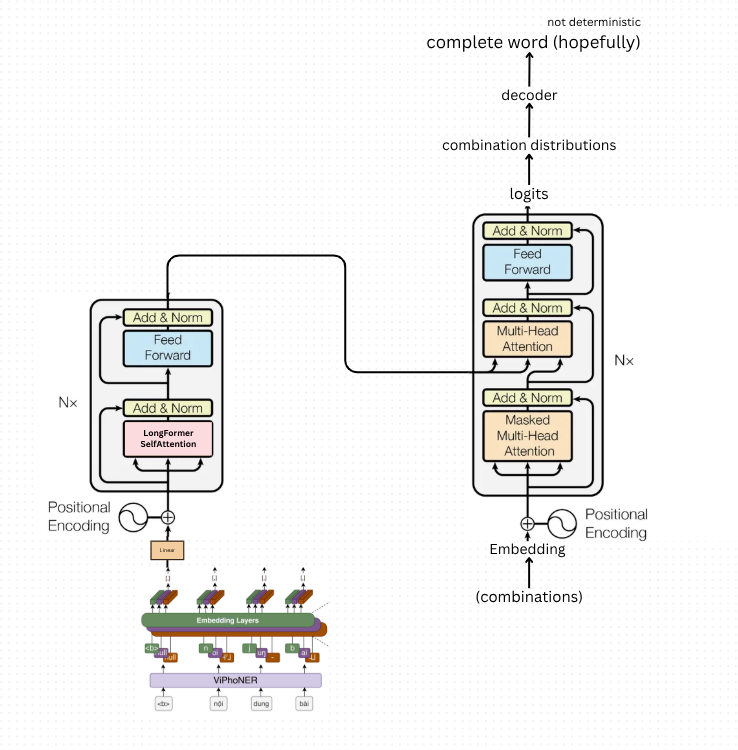